In [1]:
import pyabf
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.interpolate
import scipy.optimize

In [2]:
def average_lists(abf):
    empty_matrix = np.empty((0, 0))
    print(abf.sweepList)
    for sweepNumber in abf.sweepList:

        if sweepNumber == 0:
            current_sweep_number = abf.setSweep(sweepNumber)
            current_sweep = abf.sweepY
            time_sweep = abf.sweepX
            #Change to ms
            time_sweep = [x * 1000 for x in time_sweep]
        
            
        current_sweep_number = abf.setSweep(sweepNumber)
        current_sweep = abf.sweepY
        column_vector = np.array(abf.sweepY).reshape(-1, 1)
       
        if empty_matrix.size == 0:  # If the matrix is empty
            empty_matrix = column_vector
        else:
            empty_matrix = np.concatenate((empty_matrix, column_vector), axis=1)

    empty_matrix = np.mean(empty_matrix, axis=1)
        
    return empty_matrix,time_sweep


****start time: 0.95
end time: 0.6499999999999999
delta: 111.9812049865723
duration0.38399999999999945

****start time: 0.8999999999999999
end time: 0.5999999999999999
delta: 111.98120498657227
duration0.5139999999999993

****start time: 0.8499999999999999
end time: 0.5499999999999998
delta: 111.98120498657227
duration0.726

****start time: 0.7999999999999998
end time: 0.49999999999999983
delta: 111.98120498657227
duration0.9980000000000002

****start time: 0.7499999999999998
end time: 0.4499999999999998
delta: 111.9812049865723
duration1.3359999999999994

****start time: 0.6999999999999997
end time: 0.39999999999999974
delta: 111.98120498657224
duration1.7959999999999994

****start time: 0.6499999999999997
end time: 0.3499999999999997
delta: 111.98120498657227
duration2.3840000000000003

****start time: 0.5999999999999996
end time: 0.29999999999999966
delta: 111.98120498657225
duration3.1720000000000006

****start time: 0.5499999999999996
end time: 0.2499999999999996
delta: 111.98120

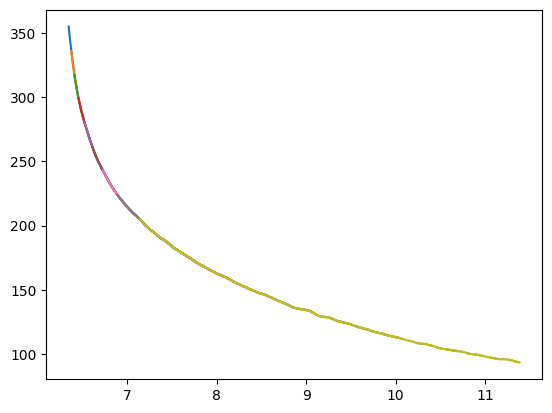

[0.2169444518998931, 0.2916386777703665, 0.3789409740099115, 0.5031614239797887, 0.7173397969151926, 1.040189572711444, 1.4654316666322813, 1.9811963980656049, 2.5591570198848275, 2.9431261353173377]


In [65]:
def calculate_tau(start):
    print(f"\n****start time: {start}")
    print(f"end time: {start-0.3}")
    threshold_start = start*max(subtracted_trace)    
    threshold_end = (start-0.3)*max(subtracted_trace)

    print(f"delta: { threshold_start-threshold_end}")

 # Find the index where the number starts decreasing and crosses the threshold
    index_start = next((i for i in range(len(subtracted_trace)-1) if subtracted_trace[i] >= threshold_start > subtracted_trace[i+1]), None)
    index_end = next((i for i in range(len(subtracted_trace)-1) if subtracted_trace[i] >= threshold_end > subtracted_trace[i+1]), None)

    if index_start is not None:
        #print(f"Threshold {threshold_start} crossed at index {index_start}.")
        #print(f"Threshold end {threshold_end} crossed at index {index_end}.")
        print(f"duration{time_sweep[index_end]-time_sweep[index_start]}")   
   
    
    
    curve = subtracted_trace[index_start:index_end]
    #curve_times_raw = time_sweep[falling_threshold_start_idx:falling_threshold_end_idx]
    curve_times = time_sweep[index_start:index_end]

    plt.plot(curve_times, curve)
        
    
#     def monoExp(t, m, tau, b):
#         return m * np.exp(-t/tau) + b
    
    
#     p0 = (400, .3, 50) # start with values near those we expect
    
#     params, cv = scipy.optimize.curve_fit(monoExp, curve_times, curve, p0)
#     m, t, b = params
#     #print(f'params {m, t, b}')
#     sampleRate = 20_000 # Hz
#     tauSec = (1 / t) / sampleRate
    
    
#     print(f"tau = {t:.07f}")
#     calculated_taus.append(t)
    
#     #print(f"I = {m:.03f} * exp(-t / {tau:.03f}) + {b:.03f}")


# calculated_taus =[]

#start_range = np.arange(0.95,0.45,-0.05)
#end_range = np.arange(0.65,0.15,-0.05)

# #print(start

# plt.figure(figsize=(6, 4))
# plt.grid(ls='--', alpha=.5)


start_range = np.arange(0.95,0.5,-0.05)


[calculate_tau(i) for i in start_range ]

# for start_val, end_val in zip(start_range, end_range):
#     print(f"start fit: {start_val} end fit:  {end_val}")
#     #print(start_val-end_val)
#     calculate_tau(start_val,start_val-0.3)



plt.show()

print(calculated_taus)









In [ ]:
Iss = b
Iprev = 0
Idss = Iss - Iprev
Ipeak = m + b
Id = Ipeak - Iprev



curve_time_array = np.asarray(curve_times)

plt.figure(figsize=(6, 4))
plt.grid(ls='--', alpha=.5)
plt.plot(curve_times, curve, '-')
plt.plot(curve_time_array, monoExp(curve_time_array, m, t, b),'--',label="fitted")
plt.xlabel("Time (milliseconds)")
plt.ylabel("Clamp Current (pA)")
#plt.savefig(f"{HERE}/mt1.png")
plt.legend(("Data", "Fit"))
plt.show()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
[2]
-88.52132415771484


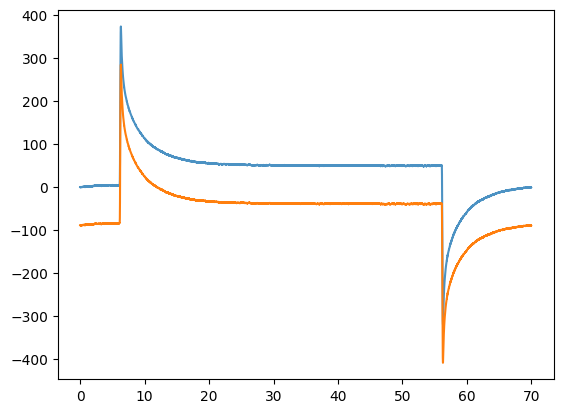

In [6]:
# Directory containing text files
directory = r"C:\Users\dw2471\OneDrive - Columbia University Irving Medical Center\Desktop\test"

# Get a list of all text files in the directory
abf_files = glob.glob(os.path.join(directory, "*.abf"))

# Sort the files by modification time (most recent first)
abf_files.sort(key=os.path.getmtime, reverse=True)

# Check if there are any text files
if abf_files:
    # Open and read the most recent text file
    most_recent_file = abf_files[0]
    abf = pyabf.ABF(most_recent_file)
    #Average all the traces
    average_trace,time_sweep = average_lists(abf)

   #Baseline calculation
    #Baseline region
    start_value = 0.003
    end_value = 0.004    

    #Calculate the indices of the baseline region
    indices = [index for index, value in enumerate(time_sweep) if start_value <= value <= end_value]
    print(indices)
    start_index = indices[0]
    end_index = indices[len(indices)-1]

    #subtract baseline region
    sub_list = average_trace[start_index:end_index + 1]
    average_bl = sum(sub_list) / len(sub_list)
    print(average_bl)
    subtracted_trace = [x - average_bl for x in average_trace]    

    plt.plot(time_sweep, subtracted_trace, alpha=.8, label="subtracted")
    plt.plot(time_sweep,average_trace)
    plt.show()

    #find_curve_fit_region(time_sweep, subtracted_trace,0.6,0.3)
    #print(type(abf))
    #print("sweep data (ADC):", abf.sweepY)
else:
    print("No text files found in the directory.")

In [3]:

# Find the index where y is closest to 60% of the maximum value

def find_curve_fit_region(time_sweep, subtracted_trace,start_region,end_region):
    index_60_percent = np.where(subtracted_trace <= start_region * max(subtracted_trace))[0][-1]    
    # Find the index where y is closest to 30% of the maximum value
    index_30_percent = np.where(subtracted_trace <= end_region * max(subtracted_trace))[0][-1]
    
    # Ensure that the index corresponding to 60% is greater than the index corresponding to 30%
    if index_60_percent > index_30_percent:
        raise ValueError("Indices are not in the correct order.")
    
    # Extract the corresponding x and y values for these points
    x_60_percent = subtracted_trace[index_60_percent]
    y_60_percent = time_sweep[index_60_percent]
    x_30_percent = subtracted_trace[index_30_percent]
    y_30_percent = time_sweep[index_30_percent]

   # print(f"x 60 percent {x_60_percent} \n x 30 percent {y_60_percent}")
    print (f"x 60 idx {index_60_percent} \n x 30 idx {index_30_percent}")
    
    curve = subtracted_trace[index_60_percent:index_30_percent]
    curve_times_raw = time_sweep[index_60_percent:index_30_percent]
    curve_times = [x - curve_times_raw[0] for x in curve_times_raw]  
    

    plt.figure(figsize=(6, 4))
    plt.grid(ls='--', alpha=.5)
    plt.plot(curve_times, curve, '-')
    plt.xlabel("Time (milliseconds)")
    plt.ylabel("Clamp Current (pA)")
    #plt.savefig(f"{HERE}/mt1.png")
    plt.show()
    
    #Define a function to fit the curve (e.g., a polynomial)
    def monoExp(t, m, tau, b):
        return m * np.exp(-t/tau) + b

    
    (m, tau, b), cv = scipy.optimize.curve_fit(monoExp, curve_times, curve, (2000, .1, 50))
    print(f"I = {m:.03f} * exp(-t / {tau:.03f}) + {b:.03f}")
    
    
   

In [151]:
from scipy.optimize import fsolve

Tau = 2.250e-3
Cap = 150e-12



# Define the equation
def equation(vars):
    Ra, Rt = vars
    return [Ra**2 - Ra * Rt + Rt * (2.250e-3/150e-12), 0]  # Adding a second equation with zero value

# Initial guess for Ra and Rt
initial_guess = [15e6, 500e6]

# Solve the equation using scipy.optimize.fsolve
solution = fsolve(equation, initial_guess)

# Extracting the values of Ra and Rt
Ra, Rt = solution

print("Solution for Ra:", Ra/1e6)
print("Solution for Rt:", Rt/1e6)


Solution for Ra: 15.479212008828519
Solution for Rt: 500.0
